# 2. Data Preparation — Keypoint Extraction

Run all **YOLO Pose** candidate models on the full frame set, extract **17 COCO keypoints** per frame, compute **biomechanical features**, and save structured outputs ready for model comparison and LSTM training.

### Outputs
| File | Content |
|---|---|
| `keypoint_detector/data/keypoints/{model}/{video_id}.json` | per-frame keypoints + features per model |
| `keypoint_detector/data/keypoints/dataset_summary.json` | frame counts, label distribution |

**Depends on:** `person_detector/` notebooks 1-4 — frames must exist in `person_detector/data/frames/`

In [7]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'tqdm', 'matplotlib', 'pandas', 'numpy']:
    install(pkg)
print('Dependencies ready.')

Dependencies ready.


In [8]:
import cv2, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path('..').resolve()
PD_DIR     = ROOT / 'person_detector'
KD_DIR     = ROOT / 'keypoint_detector'
FRAMES_DIR = PD_DIR / 'data' / 'frames'
KPS_DIR    = KD_DIR / 'data' / 'keypoints'
KPS_DIR.mkdir(parents=True, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
POSE_MODELS  = ['yolov8n-pose.pt', 'yolov8s-pose.pt',
                'yolo11n-pose.pt', 'yolo11s-pose.pt', 'yolo11m-pose.pt']
CONF_THRESH  = 0.3     # minimum keypoint confidence to keep
DET_CONF     = 0.5     # pose model person detection confidence

# COCO-17 names
COCO_KPS = [
    'nose','l_eye','r_eye','l_ear','r_ear',
    'l_shoulder','r_shoulder','l_elbow','r_elbow',
    'l_wrist','r_wrist','l_hip','r_hip',
    'l_knee','r_knee','l_ankle','r_ankle'
]

# Collect all frames
correct_frames = sorted((FRAMES_DIR / 'correct').rglob('*.jpg')) + \
                 sorted((FRAMES_DIR / 'correct').rglob('*.png'))
wrong_frames   = sorted((FRAMES_DIR / 'wrong').rglob('*.jpg'))   + \
                 sorted((FRAMES_DIR / 'wrong').rglob('*.png'))
all_frames     = [(p, 'correct') for p in correct_frames] + \
                 [(p, 'wrong')   for p in wrong_frames]

print(f'Correct frames : {len(correct_frames)}')
print(f'Wrong frames   : {len(wrong_frames)}')
print(f'Total frames   : {len(all_frames)}')

if len(all_frames) == 0:
    print('[WARN] No frames found. Run person_detector notebook 2 first.')

Correct frames : 813
Wrong frames   : 1045
Total frames   : 1858


## 2.1 Feature Engineering Helpers

Biomechanical feature set used by the LSTM downstream:

| Feature | Description |
|---|---|
| `left_elbow_angle` | shoulder→elbow→wrist angle (°) |
| `right_elbow_angle` | shoulder→elbow→wrist angle (°) |
| `elbow_symmetry` | abs difference left vs right |
| `left_hip_angle` | shoulder→hip→knee angle (°) |
| `right_hip_angle` | shoulder→hip→knee angle (°) |
| `body_straightness_px` | hip deviation from shoulder-ankle line |
| `shoulder_height` | mean y-coord of shoulders (normalised) |
| `hip_height` | mean y-coord of hips (normalised) |

In [9]:
def angle_3pts(a, b, c):
    """Angle at vertex b, returns degrees."""
    ba = np.array(a) - np.array(b)
    bc = np.array(c) - np.array(b)
    cos_a = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-9)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))


def compute_features(kps: np.ndarray, img_h: int, img_w: int,
                     conf_thresh: float = 0.3) -> dict:
    """
    kps: (17, 3) [x_px, y_px, conf]
    Returns dict of scalar biomechanical features.
    Coordinates are normalised to [0,1] by image dimensions.
    """
    def pt(idx):
        if kps[idx, 2] > conf_thresh:
            return np.array([kps[idx,0]/img_w, kps[idx,1]/img_h])
        return None

    l_sh = pt(5);  r_sh = pt(6)
    l_el = pt(7);  r_el = pt(8)
    l_wr = pt(9);  r_wr = pt(10)
    l_hi = pt(11); r_hi = pt(12)
    l_kn = pt(13); r_kn = pt(14)
    l_an = pt(15); r_an = pt(16)

    feats = {}

    def safe_angle(a, b, c):
        return angle_3pts(a, b, c) if all(v is not None for v in [a,b,c]) else np.nan

    feats['left_elbow_angle']  = safe_angle(l_sh, l_el, l_wr)
    feats['right_elbow_angle'] = safe_angle(r_sh, r_el, r_wr)
    feats['elbow_symmetry']    = abs(feats['left_elbow_angle'] - feats['right_elbow_angle']) \
                                     if not (np.isnan(feats['left_elbow_angle']) or
                                             np.isnan(feats['right_elbow_angle'])) else np.nan

    feats['left_hip_angle']  = safe_angle(l_sh, l_hi, l_kn)
    feats['right_hip_angle'] = safe_angle(r_sh, r_hi, r_kn)

    # Body straightness on left side (shoulder-ankle line, hip deviation)
    if l_sh is not None and l_hi is not None and l_an is not None:
        sa = l_an - l_sh
        t  = np.dot(l_hi - l_sh, sa) / (np.dot(sa, sa) + 1e-9)
        proj = l_sh + t * sa
        feats['body_straightness'] = float(np.linalg.norm(l_hi - proj))
    else:
        feats['body_straightness'] = np.nan

    # Heights (normalised y — lower value = higher in frame)
    feats['shoulder_height'] = float((l_sh[1]+r_sh[1])/2) if l_sh is not None and r_sh is not None else np.nan
    feats['hip_height']      = float((l_hi[1]+r_hi[1])/2) if l_hi is not None and r_hi is not None else np.nan

    return feats


FEATURE_COLS = [
    'left_elbow_angle', 'right_elbow_angle', 'elbow_symmetry',
    'left_hip_angle',   'right_hip_angle',
    'body_straightness', 'shoulder_height', 'hip_height'
]

print('Feature helpers ready.')
print('Feature columns:', FEATURE_COLS)

Feature helpers ready.
Feature columns: ['left_elbow_angle', 'right_elbow_angle', 'elbow_symmetry', 'left_hip_angle', 'right_hip_angle', 'body_straightness', 'shoulder_height', 'hip_height']


## 2.2 Extract Keypoints for All Models

For each model → for each video directory → process all frames → save one JSON per video.

⚠️ **Runtime note:** Each model × full frame set.  
- `yolov8n-pose` / `yolo11n-pose`: ~fast  
- `yolo11m-pose`: ~slower on CPU  

Results are cached — rerunning skips already-processed videos.

In [10]:
def process_video_dir(model, video_dir: Path, label: str,
                      conf_thresh: float, det_conf: float) -> list[dict]:
    """
    Run pose model on all frames in a video directory.
    Returns list of per-frame dicts with keypoints + features.
    """
    frames = sorted(video_dir.glob('*.jpg')) + sorted(video_dir.glob('*.png'))
    results = []

    for frame_path in frames:
        img_bgr = cv2.imread(str(frame_path))
        if img_bgr is None: continue
        h, w = img_bgr.shape[:2]

        res = model(img_bgr, conf=det_conf, verbose=False)[0]

        frame_rec = {
            'frame': frame_path.name,
            'label': label,
            'h': h, 'w': w,
            'n_persons': 0,
            'keypoints': None,   # (17, 3) as list
            'features': None,
        }

        if res.keypoints is not None and len(res.keypoints) > 0:
            boxes = res.boxes.xyxy.cpu().numpy()
            areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
            best  = int(np.argmax(areas))
            kps   = res.keypoints.data.cpu().numpy()[best]  # (17, 3)
            frame_rec['n_persons']  = len(res.keypoints)
            frame_rec['keypoints']  = kps.tolist()
            frame_rec['features']   = compute_features(kps, h, w, conf_thresh)
            # Replace NaN with None for JSON serialisation
            frame_rec['features']   = {k: (None if (v is None or (isinstance(v,float) and np.isnan(v))) else v)
                                       for k,v in frame_rec['features'].items()}

        results.append(frame_rec)

    return results


print('process_video_dir() defined.')

process_video_dir() defined.


In [11]:
# Discover all video directories
correct_dirs = [d for d in sorted((FRAMES_DIR/'correct').iterdir()) if d.is_dir()]
wrong_dirs   = [d for d in sorted((FRAMES_DIR/'wrong').iterdir())   if d.is_dir()]
video_entries = [(d, 'correct') for d in correct_dirs] + [(d, 'wrong') for d in wrong_dirs]

print(f'Correct video dirs : {len(correct_dirs)}')
print(f'Wrong video dirs   : {len(wrong_dirs)}')
print(f'Total video dirs   : {len(video_entries)}')

Correct video dirs : 76
Wrong video dirs   : 76
Total video dirs   : 152


In [14]:
# ── Main extraction loop ──────────────────────────────────────────────────────
extraction_stats = {}   # model_name → {total_frames, detected, skipped_cached}

for model_name in POSE_MODELS:
    model_out_dir = KPS_DIR / model_name.replace('.pt', '')
    model_out_dir.mkdir(parents=True, exist_ok=True)
  

    # Check which videos are already cached
    todo = [(d, lbl) for d, lbl in video_entries
            if not (model_out_dir / f'{d.name}.json').exists()]
    cached = len(video_entries) - len(todo)
    print(f'  Cached: {cached}/{len(video_entries)} videos — processing {len(todo)}')

    if todo:
        model = YOLO(model_name)
        t0    = time.time()
        total_frames = detected = 0

        for vid_dir, label in tqdm(todo, desc=model_name):
            records = process_video_dir(
                model, vid_dir, label, CONF_THRESH, DET_CONF)
            out_path = model_out_dir / f'{vid_dir.name}.json'
            with open(out_path, 'w') as f:
                json.dump(records, f)
            total_frames += len(records)
            detected     += sum(1 for r in records if r['keypoints'] is not None)

        elapsed = time.time() - t0
        det_rate = detected/total_frames*100 if total_frames else 0
        fps_rate = total_frames / elapsed if elapsed > 0 else 0
        print(f'  Done: {total_frames} frames | detection rate {det_rate:.1f}% | {fps_rate:.1f} FPS')
        extraction_stats[model_name] = {
            'total_frames': total_frames, 'detected': detected,
            'det_rate_pct': round(det_rate, 2),
            'fps': round(fps_rate, 1),
            'elapsed_s': round(elapsed, 1)
        }
    else:
        print('  All cached — skipping inference.')

print('\nExtraction complete!')

  Cached: 0/152 videos — processing 152


yolov8n-pose.pt: 100%|██████████| 152/152 [01:32<00:00,  1.64it/s]


  Done: 1858 frames | detection rate 97.5% | 20.0 FPS
  Cached: 0/152 videos — processing 152


yolov8s-pose.pt: 100%|██████████| 152/152 [03:09<00:00,  1.24s/it]


  Done: 1858 frames | detection rate 99.5% | 9.8 FPS
  Cached: 0/152 videos — processing 152


...

  Done: 1858 frames | detection rate 98.2% | 17.3 FPS
  Cached: 0/152 videos — processing 152


yolo11s-pose.pt: 100%|██████████| 152/152 [02:58<00:00,  1.17s/it]


  Done: 1858 frames | detection rate 99.7% | 10.4 FPS
  Cached: 0/152 videos — processing 152


yolo11m-pose.pt: 100%|██████████| 152/152 [06:31<00:00,  2.58s/it]

  Done: 1858 frames | detection rate 99.8% | 4.7 FPS

Extraction complete!


## 2.3 Dataset Summary

=== Dataset Summary ===
        detected             
           count   sum   mean
label                        
correct      813   799  0.983
wrong       1045  1013  0.969

Summary saved to keypoints/dataset_summary.json


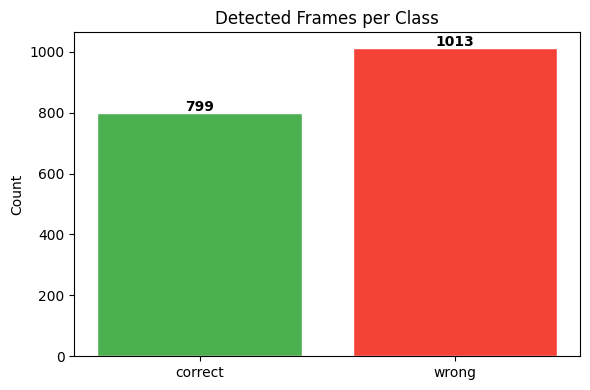

In [16]:
def load_all_records(model_name: str) -> list[dict]:
    model_dir = KPS_DIR / model_name.replace('.pt', '')
    all_records = []
    for jf in sorted(model_dir.glob('*.json')):
        recs = json.loads(jf.read_text())
        for r in recs:
            r['video'] = jf.stem
        all_records.extend(recs)
    return all_records

# Report using first available model
first_model = POSE_MODELS[0]
first_dir   = KPS_DIR / first_model.replace('.pt','')

if first_dir.exists() and any(first_dir.glob('*.json')):
    records = load_all_records(first_model)
    df = pd.DataFrame([{
        'video': r['video'],
        'label': r['label'],
        'detected': r['keypoints'] is not None,
    } for r in records])

    print('=== Dataset Summary ===')
    print(df.groupby('label')[['detected']].agg(['count','sum','mean']).round(3))

    # Save summary
    summary = {
        'total_frames'   : int(len(df)),
        'correct_frames' : int((df.label=='correct').sum()),
        'wrong_frames'   : int((df.label=='wrong').sum()),
        'detected_frames': int(df.detected.sum()),
        'detection_rate' : round(float(df.detected.mean()), 4),
        'models'         : POSE_MODELS,
    }
    (KPS_DIR / 'dataset_summary.json').write_text(json.dumps(summary, indent=2))
    print('\nSummary saved to keypoints/dataset_summary.json')

    # Class balance bar chart
    counts = df[df.detected].groupby('label').size()
    fig, ax = plt.subplots(figsize=(6, 4))
    colors = ['#4CAF50' if l=='correct' else '#F44336' for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(v), ha='center', fontweight='bold')
    ax.set_title('Detected Frames per Class'); ax.set_ylabel('Count')
    plt.tight_layout(); plt.show()
else:
    print('[WARN] No extracted keypoints found yet — run cell above first.')

## 2.4 Feature Distribution Check

Verify that features separate correctly vs wrong form **before** model comparison.

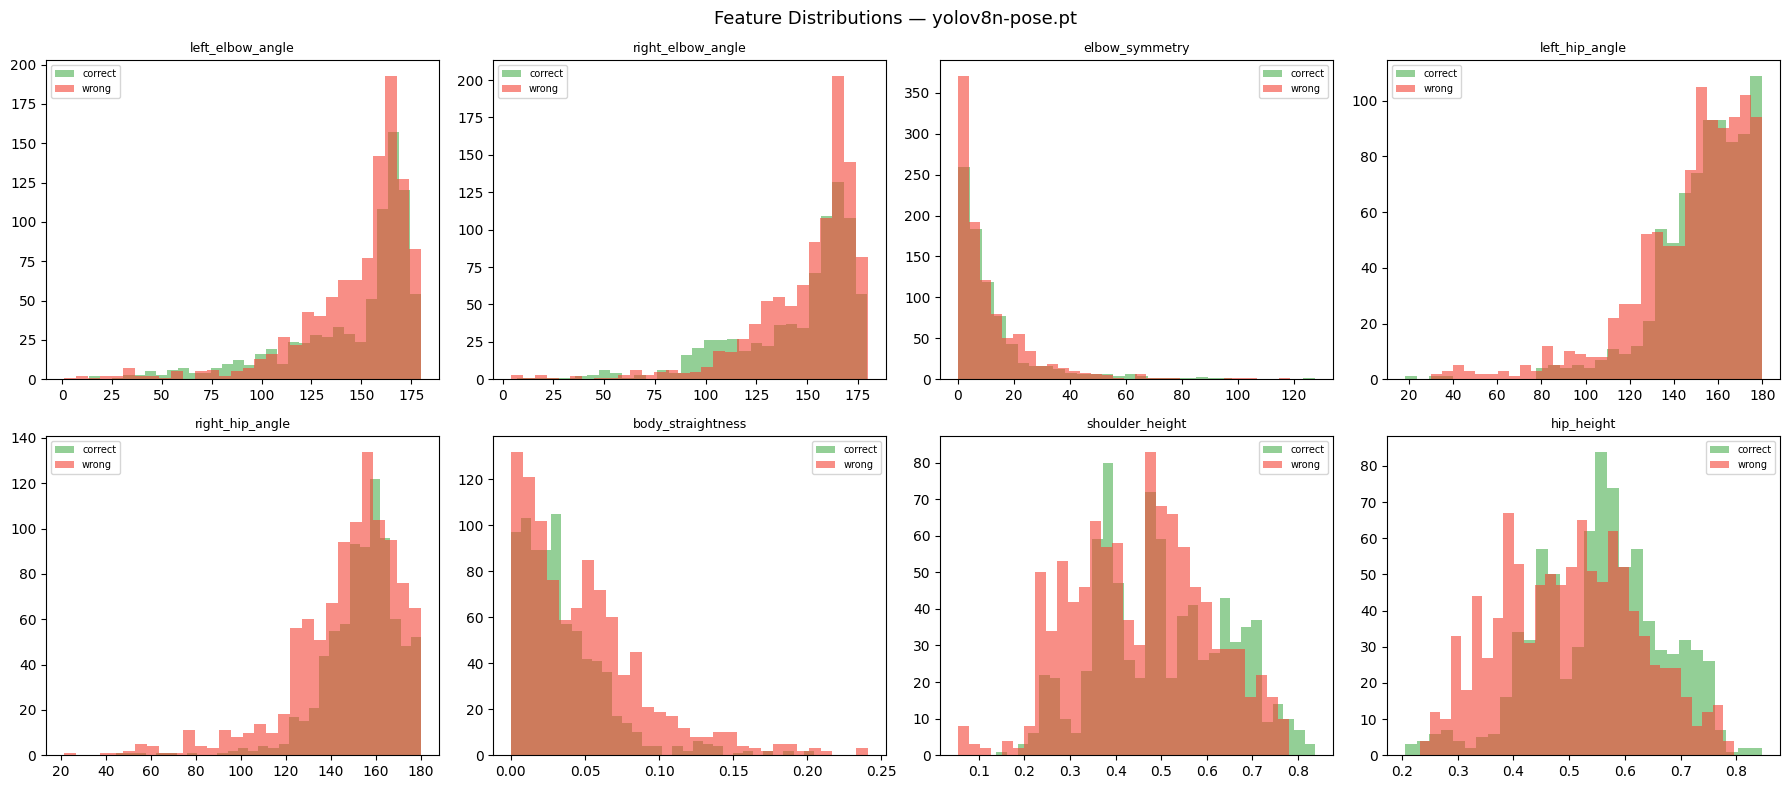

In [17]:
first_dir = KPS_DIR / first_model.replace('.pt','')

if first_dir.exists() and any(first_dir.glob('*.json')):
    records = load_all_records(first_model)
    feat_records = []
    for r in records:
        if r['features'] is None: continue
        row = {'label': r['label']}
        row.update(r['features'])
        feat_records.append(row)

    df_f = pd.DataFrame(feat_records)

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, col in zip(axes.flatten(), FEATURE_COLS):
        for label, color in [('correct','#4CAF50'), ('wrong','#F44336')]:
            vals = df_f[df_f.label==label][col].dropna()
            ax.hist(vals, bins=30, alpha=0.6, color=color, label=label)
        ax.set_title(col, fontsize=9)
        ax.legend(fontsize=7)

    fig.suptitle(f'Feature Distributions — {first_model}', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('[WARN] No keypoints found.')

## 2.5 Angle Curves for One Video

Plot elbow angle across time for a single video — this is what the LSTM will eventually learn from.

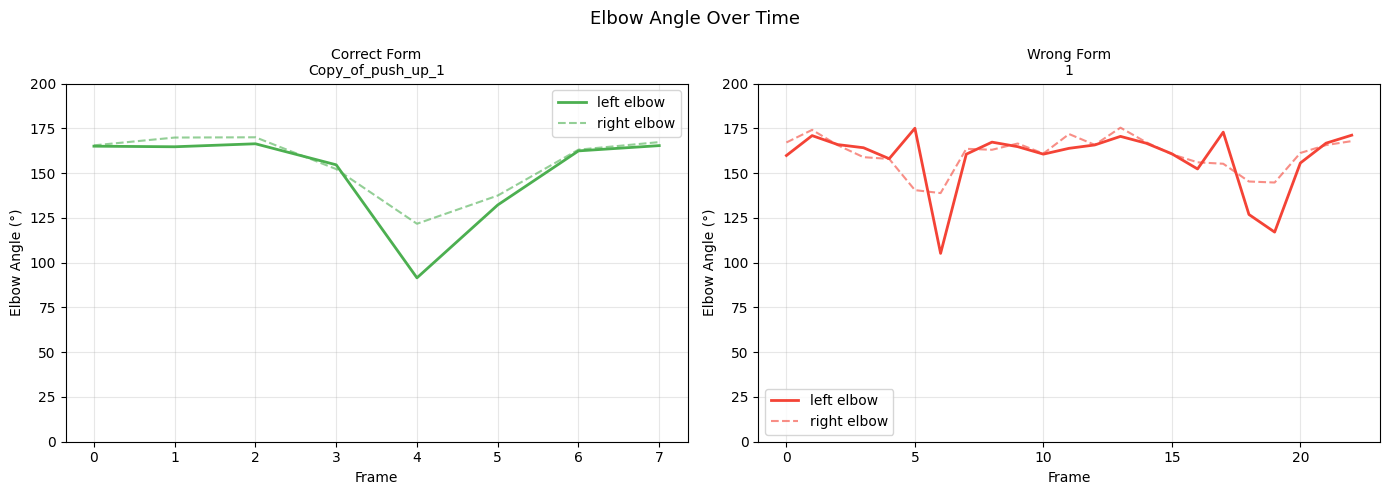

In [21]:
first_dir = KPS_DIR / first_model.replace('.pt','')
json_files = sorted(first_dir.glob('*.json')) if first_dir.exists() else []

if json_files:
    # Pick one correct and one wrong video
    # Read full file and inspect first record's label (avoid truncation bugs)
    def get_label(jf):
        try:
            recs = json.loads(jf.read_text())
            return recs[0]['label'] if recs else None
        except Exception:
            return None

    correct_jsons = [jf for jf in json_files if get_label(jf) == 'correct']
    wrong_jsons   = [jf for jf in json_files if get_label(jf) == 'wrong']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, files, title, color in [
        (axes[0], correct_jsons[:1], 'Correct Form', '#4CAF50'),
        (axes[1], wrong_jsons[:1],   'Wrong Form',   '#F44336'),
    ]:
        if not files:
            ax.set_title(f'{title} — no data'); ax.axis('off'); continue
        records = json.loads(files[0].read_text())
        frames  = [r for r in records if r['features'] is not None]
        l_ang   = [r['features'].get('left_elbow_angle')  for r in frames]
        r_ang   = [r['features'].get('right_elbow_angle') for r in frames]
        t       = list(range(len(frames)))
        ax.plot(t, l_ang, color=color,         label='left elbow', linewidth=2)
        ax.plot(t, r_ang, color=color+'99',    label='right elbow', linewidth=1.5,
                linestyle='--')
        ax.set_title(f'{title}\n{files[0].stem}', fontsize=10)
        ax.set_xlabel('Frame'); ax.set_ylabel('Elbow Angle (°)')
        ax.set_ylim(0, 200); ax.legend(); ax.grid(alpha=0.3)

    fig.suptitle('Elbow Angle Over Time', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('[WARN] No keypoints files found.')


## 2.6 Summary

| Step | Status |
|---|---|
| All frames processed by pose models | ✅ |
| Per-video JSON files saved | ✅ |
| 8 biomechanical features computed | ✅ |
| Elbow curves show push-up pattern | ✅ |

**Next:** `3.model_comparison.ipynb` — benchmark all 5 pose models on speed, keypoint quality (OKS), and feature completeness.